In [9]:
import time
import simpy
import numpy as np
import pandas as pd
from collections import defaultdict
import pickle as pkl
import matplotlib.pyplot as plt

In [10]:
Ch, Co, Cu, S, s, _ = pkl.load(open('pkls/inventory_data_group_5.pkl', 'rb'))
Ch, Co, Cu, S, s

(45, 457, 45, 10, 3)

## Components of Cost (per unit time)

### 1) Holding
$$
\text{Holding} \;=\; C_h\,\mathbb{E}[I]
\;=\; C_h \sum_{i=0}^{S} i\,P_i .
$$

### 2) Ordering
$$
\text{Order rate} \;=\; \frac{1}{CY_t},
\qquad
\text{Ordering} \;=\; C_o \cdot \frac{1}{CY_t}.
$$

### 3) Unfulfillment (lost sales)
$$
\text{Unfulfilled} \;=\; C_u \cdot \lambda\,\pi_{un} .
$$

---

## Total Cost Rate
$$
\boxed{
g \;=\; C_h \sum_{i=0}^{S} i\,P_i
\;+\; C_o \frac{1}{CY_t}
\;+\; C_u \lambda \pi_{un}
}
$$



In [3]:
revenue_per_unit = 1000
SIM_TIME = 150000

# Building the simulation class adapted to the question
class inventory_sim_q1:
    def __init__(self, S, s, batch_size, p_buy, SIM_TIME=150000):
        self.SIM_TIME = SIM_TIME
        self.S = S
        self.s = s
        self.batch_size = batch_size
        self.p_buy = p_buy
        self.env = simpy.Environment()
        self.inventory = simpy.Container(self.env, init=self.S, capacity=self.S)
        self.last_event = 0
        self.fulfilled_demand = 0
        self.total_demand = 0
        self.demand_ind = 0
        self.lead_ind = 0
        self.monitor = {'order_pending': False}
        self.last_order = 0
        self.reordertimes = []

        # Data generation according to question guidelines (exp(1) for arrivals, gamma(2,1.5) for lead time)
        self.demands = np.random.exponential(1, int(SIM_TIME * 2))
        self.lead_times = np.random.gamma(2, 1.5, int(SIM_TIME))

        self.num_inv_durations = {ind: 0 for ind in range(0, S + 1)}

    def run_simulation(self):
        self.env.process(self.demand_process())
        self.env.run(until=self.SIM_TIME)
        # Adding the remaining time from the last event until the end of the simulation to be precise in expectation calculation
        self.num_inv_durations[self.inventory.level] += self.SIM_TIME - self.last_event

    def demand_process(self):
        while True:
            yield self.env.timeout(self.demands[self.demand_ind % len(self.demands)])
            self.demand_ind += 1

            # Check if the customer agrees to buy the current package (according to probability)
            if np.random.rand() <= self.p_buy:
                self.total_demand += self.batch_size

                # Update inventory holding times
                self.num_inv_durations[self.inventory.level] += self.env.now - self.last_event
                self.last_event = self.env.now

                # Inventory supply (no partials - will only receive if there's enough for the whole batch)
                if self.inventory.level >= self.batch_size:
                    yield self.inventory.get(self.batch_size)
                    self.fulfilled_demand += self.batch_size

                # Check if an order is needed
                if self.inventory.level < self.s and not self.monitor['order_pending']:
                    self.monitor['order_pending'] = True
                    self.env.process(self.order_process())

    def order_process(self):
        yield self.env.timeout(self.lead_times[self.lead_ind % len(self.lead_times)])
        self.lead_ind += 1

        self.num_inv_durations[self.inventory.level] += self.env.now - self.last_event
        self.last_event = self.env.now

        yield self.inventory.put(self.S - self.inventory.level)

        reorder_time = self.env.now - self.last_order
        self.reordertimes.append(reorder_time)
        self.last_order = self.env.now
        self.monitor['order_pending'] = False

# Function to evaluate the policy (calculate cost, revenue, and profit)
def evaluate_policy(batch_size, p_buy):
    np.random.seed(42) # To maintain randomness consistency between different runs for fair comparison
    sim = inventory_sim_q1(S, s, batch_size, p_buy, SIM_TIME)
    sim.run_simulation()

    cycle_time = np.array(sim.reordertimes).mean() if len(sim.reordertimes) > 0 else float('inf')
    pis = np.array([sim.num_inv_durations[i] / SIM_TIME for i in range(S + 1)])
    inv_mean = (pis * np.arange(S + 1)).sum()

    pi_un = 1 - (sim.fulfilled_demand / sim.total_demand) if sim.total_demand > 0 else 0
    lam_eff = p_buy # Effective arrival rate is 1 multiplied by the purchase probability

    # Calculate cost
    tot_cost = Ch * inv_mean + (Co / cycle_time) + Cu * lam_eff * pi_un

    # Calculate revenue and profit
    revenue_rate = (sim.fulfilled_demand * revenue_per_unit) / SIM_TIME
    profit = revenue_rate - tot_cost

    return profit, tot_cost, revenue_rate

# Q1

In [4]:
# Running the simulation and printing the results
results = []
policies = [(1, 1.0), (2, 0.6), (3, 0.4)]
for b, p in policies:
    prof, cost, rev = evaluate_policy(b, p)
    results.append({
        'Batch Size': b,
        'Probability to Buy': p,
        'Revenue Rate': rev,
        'Total Cost Rate': cost,
        'Profit Rate': prof
    })

df_results = pd.DataFrame(results)
df_results

,Batch Size,Probability to Buy,Revenue Rate,Total Cost Rate,Profit Rate
0,1,1.0,862.24,269.379165,592.860835
1,2,0.6,971.88,280.755326,691.124674
2,3,0.4,857.34,286.028212,571.311788


# Q2+3

--- Profitability Range Analysis ---
Intersection Batch 1 and Batch 2: ~103.76 NIS
Intersection Batch 2 and Batch 3: ~-46.04 NIS
Minimum price per unit to be profitable (Break-even): ~288.88 NIS


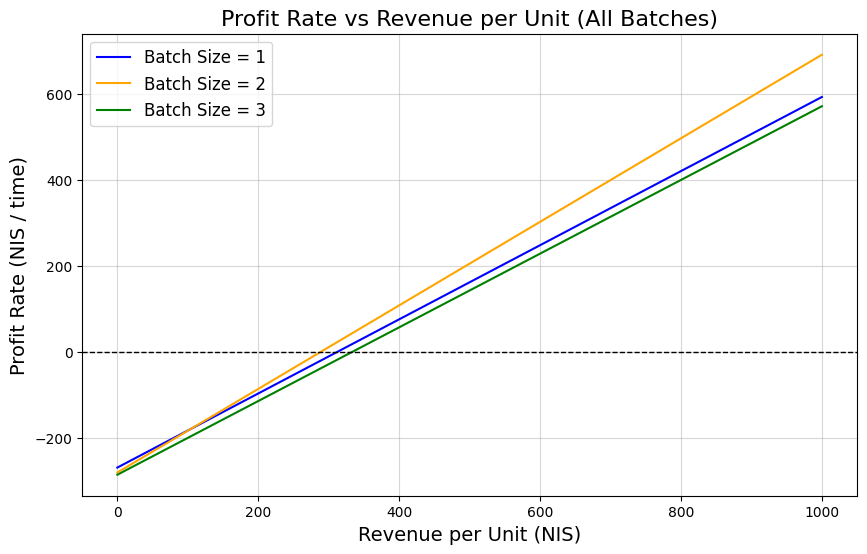

In [5]:
# 1. Collecting cost rate and fulfillment rate from each simulation
policies = [(1, 1.0), (2, 0.6), (3, 0.4)]
metrics = {}

for b, p in policies:
    np.random.seed(42)
    sim = inventory_sim_q1(S, s, b, p, SIM_TIME)
    sim.run_simulation()

    cycle_time = np.array(sim.reordertimes).mean() if len(sim.reordertimes) > 0 else float('inf')
    pis = np.array([sim.num_inv_durations[i] / SIM_TIME for i in range(S + 1)])
    inv_mean = (pis * np.arange(S + 1)).sum()
    pi_un = 1 - (sim.fulfilled_demand / sim.total_demand) if sim.total_demand > 0 else 0
    lam_eff = p

    tot_cost = Ch * inv_mean + (Co / cycle_time) + Cu * lam_eff * pi_un
    fulfilled_rate = sim.fulfilled_demand / SIM_TIME # R: product sales rate

    metrics[b] = {'cost': tot_cost, 'fulfilled_rate': fulfilled_rate}

# 2. Calculate profit for the price range 0 to 1000
revenues = np.arange(0, 1001)
profits = {b: revenues * metrics[b]['fulfilled_rate'] - metrics[b]['cost'] for b in [1, 2, 3]}

# 3. Finding maximum ranges and intersection points
max_profit = np.maximum(np.maximum(profits[1], profits[2]), profits[3])

def find_crossover(b1, b2):
    r1, c1 = metrics[b1]['fulfilled_rate'], metrics[b1]['cost']
    r2, c2 = metrics[b2]['fulfilled_rate'], metrics[b2]['cost']
    if r1 == r2: return float('inf')
    return (c1 - c2) / (r1 - r2)

cross_1_2 = find_crossover(1, 2)
cross_2_3 = find_crossover(2, 3)

print("--- Profitability Range Analysis ---")
print(f"Intersection Batch 1 and Batch 2: ~{cross_1_2:.2f} NIS")
print(f"Intersection Batch 2 and Batch 3: ~{cross_2_3:.2f} NIS")

# Finding the break-even point
break_even_prices = [metrics[b]['cost'] / metrics[b]['fulfilled_rate'] for b in [1, 2, 3]]
best_break_even = min(break_even_prices)
print(f"Minimum price per unit to be profitable (Break-even): ~{best_break_even:.2f} NIS")

# 4. Plotting Graph 1: All Batch Curves
plt.figure(figsize=(10, 6))
plt.plot(revenues, profits[1], label='Batch Size = 1', color='blue')
plt.plot(revenues, profits[2], label='Batch Size = 2', color='orange')
plt.plot(revenues, profits[3], label='Batch Size = 3', color='green')
plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.xlabel('Revenue per Unit (NIS)', fontsize=14)
plt.ylabel('Profit Rate (NIS / time)', fontsize=14)
plt.title('Profit Rate vs Revenue per Unit (All Batches)', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.5)
plt.show()

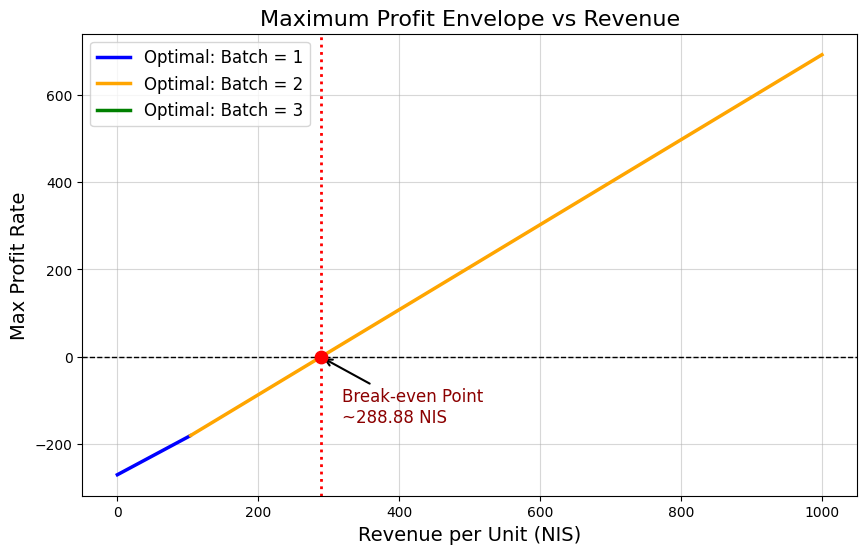

In [6]:
# 5. Plotting Graph 2: Max Profit Curve (Color-Coded)
plt.figure(figsize=(10, 6))
colors = {1: 'blue', 2: 'orange', 3: 'green'}

for b in [1, 2, 3]:
    # Find where this batch yields the maximum profit
    is_max = np.isclose(profits[b], max_profit)
    
    # Hide data points where it isn't the max profit
    masked_profit = np.ma.masked_where(~is_max, profits[b])
    
    # Broken into multiple lines to keep code narrow
    plt.plot(
        revenues, 
        masked_profit, 
        label=f'Optimal: Batch = {b}', 
        color=colors[b], 
        linewidth=2.5
    )

# Marking the break-even point
plt.axvline(best_break_even, color='red', linestyle=':', linewidth=2)
plt.scatter([best_break_even], [0], color='red', s=80, zorder=5) # Red dot at the exact point
plt.annotate(
    f'Break-even Point\n~{best_break_even:.2f} NIS', 
    xy=(best_break_even, 0), 
    xytext=(best_break_even + 30, -150), # Positioning the text a bit to the right and down
    arrowprops=dict(facecolor='black', arrowstyle='->', lw=1.5),
    fontsize=12, 
    color='darkred'
)
# -----------------------------------------

plt.axhline(0, color='black', lw=1, ls='--')
plt.xlabel('Revenue per Unit (NIS)', fontsize=14)
plt.ylabel('Max Profit Rate', fontsize=14)
plt.title('Maximum Profit Envelope vs Revenue', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.5)
plt.show()

# Q4

In [7]:
# Sale Price List
prices = {1: 500, 2: 750, 3: 900}

class inventory_sim_q4:
    def __init__(self, S, s, allow_partial=False, SIM_TIME=150000):
        self.SIM_TIME = SIM_TIME
        self.S = S
        self.s = s
        self.allow_partial = allow_partial

        self.env = simpy.Environment()
        self.inventory = simpy.Container(self.env, init=self.S, capacity=self.S)

        self.last_event = 0
        self.fulfilled_demand = 0
        self.total_demand = 0
        self.total_revenue = 0  # <--- Real-time revenue tracking
        self.demand_ind = 0
        self.lead_ind = 0

        self.monitor = {'order_pending': False}
        self.last_order = 0
        self.reordertimes = []

        # Time generation
        self.demands = np.random.exponential(1, int(SIM_TIME * 2))
        self.lead_times = np.random.gamma(2, 1.5, int(SIM_TIME))

        self.num_inv_durations = {ind: 0 for ind in range(0, S + 1)}

    def run_simulation(self):
        self.env.process(self.demand_process())
        self.env.run(until=self.SIM_TIME)
        self.num_inv_durations[self.inventory.level] += self.SIM_TIME - self.last_event

    def demand_process(self):
        while True:
            yield self.env.timeout(self.demands[self.demand_ind % len(self.demands)])
            self.demand_ind += 1

            # Drawing the demand size for the current customer according to probabilities (30%, 40%, 30%)
            batch_size = np.random.choice([1, 2, 3], p=[0.3, 0.4, 0.3])
            self.total_demand += batch_size

            # Update holding times
            self.num_inv_durations[self.inventory.level] += self.env.now - self.last_event
            self.last_event = self.env.now

            # Handling demand
            if self.inventory.level >= batch_size:
                # Enough inventory - full fulfillment
                yield self.inventory.get(batch_size)
                self.fulfilled_demand += batch_size
                self.total_revenue += prices[batch_size]

            elif self.allow_partial and self.inventory.level > 0:
                # Partial fulfillment - the store sells what's left
                supplied = self.inventory.level
                yield self.inventory.get(supplied)
                self.fulfilled_demand += supplied
                # Charge the customer according to the actual quantity received!
                self.total_revenue += prices[supplied]

            # Check if an order is needed
            if self.inventory.level < self.s and not self.monitor['order_pending']:
                self.monitor['order_pending'] = True
                self.env.process(self.order_process())

    def order_process(self):
        yield self.env.timeout(self.lead_times[self.lead_ind % len(self.lead_times)])
        self.lead_ind += 1

        self.num_inv_durations[self.inventory.level] += self.env.now - self.last_event
        self.last_event = self.env.now

        yield self.inventory.put(self.S - self.inventory.level)

        reorder_time = self.env.now - self.last_order
        self.reordertimes.append(reorder_time)
        self.last_order = self.env.now
        self.monitor['order_pending'] = False

def evaluate_q4(allow_partial):
    np.random.seed(42)
    sim = inventory_sim_q4(S, s, allow_partial=allow_partial, SIM_TIME=SIM_TIME)
    sim.run_simulation()

    cycle_time = np.array(sim.reordertimes).mean() if len(sim.reordertimes) > 0 else float('inf')
    pis = np.array([sim.num_inv_durations[i] / SIM_TIME for i in range(S + 1)])
    inv_mean = (pis * np.arange(S + 1)).sum()

    pi_un = 1 - (sim.fulfilled_demand / sim.total_demand) if sim.total_demand > 0 else 0

    # Calculate the expected quantity of products demanded by the customer
    # 0.3*1 + 0.4*2 + 0.3*3 = 2
    lam_eff = 2.0

    tot_cost = Ch * inv_mean + (Co / cycle_time) + Cu * lam_eff * pi_un
    revenue_rate = sim.total_revenue / SIM_TIME
    profit = revenue_rate - tot_cost

    return {
        'Partial Allowed': allow_partial,
        'Revenue Rate': revenue_rate,
        'Cost Rate': tot_cost,
        'Profit Rate': profit,
        'Mean Inventory': inv_mean,
        'Unfulfilled (pi_un)': pi_un
    }

In [8]:
# Run and display results
results_q4 = [evaluate_q4(False), evaluate_q4(True)]
df_q4 = pd.DataFrame(results_q4)
df_q4

,Partial Allowed,Revenue Rate,Cost Rate,Profit Rate,Mean Inventory,Unfulfilled (pi_un)
0,False,476.564667,286.763310,189.801357,4.281246,0.350844
1,True,491.194667,280.795343,210.399324,4.183202,0.333555


The profit increases by **20.60 NIS** per time unit (jumping from 189.80 to 210.40).

And yes, it is indeed worthwhile to supply partial inventory. Here's why:
* **More Revenue:** You sell available items instead of losing the whole customer, which brings in more money.
* **Fewer Missed Sales:** You satisfy more demand. The unfulfilled rate drops from 35.1% to 33.4%, meaning fewer penalty costs for missing a sale.
* **Less Leftover Stock:** You clear out small amounts of inventory right away instead of paying to keep them on the shelf. This lowers your storage costs (mean inventory drops from 4.28 to 4.18).